In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle

# Notebook description

* This Notebook generates simulated price/temperature data to use in the thesis.
* We will discuss with the student how many days (n_days) and horizons (n_horizons) are required.
* The simulated results are stored in a dictionary (sims_dict)
* For conveniance, after generating the data the student can save it in a pickle file useing the code snippet below.

In [2]:

np.random.seed(42)

# ============================================================
# 1. SETUP
# ============================================================

n_days = 10
n_paths = 5000
n_horizons = 8760  # 365*24

asof_dates = pd.date_range("2020-01-01", periods=n_days, freq="D")
hours = np.arange(1, n_horizons + 1)
path_cols = [f"path_{i}" for i in range(1, n_paths + 1)]

series_names = ["price", "temp"]

sims_dict = {}
realized_dict = {s: pd.DataFrame(index=asof_dates, columns=hours, dtype=float)
                 for s in series_names}

# ============================================================
# 2. FAKE JOINT SIMULATIONS (price & temperature)
# ============================================================

base_price = 50.0
amp_price_day = 10.0          # intraday amplitude
amp_price_year = 5.0          # yearly amplitude (keep modest)

base_temp = 10.0
amp_temp_day = 8.0            # intraday amplitude
amp_temp_year = 12.0          # yearly amplitude (bigger seasonal swing)

sigma_price = 5.0
sigma_temp = 3.0
rho = 0.5

cov = np.array([
    [sigma_price**2, rho * sigma_price * sigma_temp],
    [rho * sigma_price * sigma_temp, sigma_temp**2]
])

# Precompute Cholesky for fast correlated shocks
L = np.linalg.cholesky(cov)  # cov = L @ L.T

for asof in asof_dates:
    # Build an hourly datetime index for the horizon starting at asof
    dt_index = pd.date_range(asof, periods=n_horizons, freq="h")

    # Intraday seasonality (hour of day)
    hod = dt_index.hour.values  # 0..23
    day_phase = 2 * np.pi * hod / 24.0

    # NEW: Yearly seasonality (day of year)
    doy = dt_index.dayofyear.values  # 1..365/366
    year_phase = 2 * np.pi * (doy - 1) / 365.0  # keep 365 for simplicity

    # Hourly means (shape: n_horizons,)
    mean_price = (
    base_price
    + amp_price_day * (
        0.8 * np.sin(day_phase - np.pi) +
        0.2 * np.sin(2 * (day_phase - np.pi))
    )
    + amp_price_year * np.cos(year_phase)
    )

    mean_temp = (
    base_temp
    - amp_temp_day * np.cos(2 * np.pi * (hod - 5) / 24.0)
    + amp_temp_year * np.cos(year_phase + np.pi)
    )

    # Draw all shocks at once: Z ~ N(0, I), then eps = Z @ L.T
    Z = np.random.normal(size=(n_horizons, n_paths, 2))            # iid
    eps = Z @ L.T                                                 # correlated

    sims_price = mean_price[:, None] + eps[:, :, 0]
    sims_temp  = mean_temp[:, None]  + eps[:, :, 1]

    # Realized values: one draw per hour (same distribution)
    Z_real = np.random.normal(size=(n_horizons, 2))
    eps_real = Z_real @ L.T
    realized_price = mean_price + eps_real[:, 0]
    realized_temp  = mean_temp  + eps_real[:, 1]

    realized_dict["price"].loc[asof, :] = realized_price
    realized_dict["temp"].loc[asof, :]  = realized_temp

    df_price = pd.DataFrame(sims_price, index=hours, columns=path_cols)
    df_temp  = pd.DataFrame(sims_temp,  index=hours, columns=path_cols)

    sims_dict[asof] = {"price": df_price, "temp": df_temp}


In [3]:
#Example output: Temperature
sims_dict[pd.Timestamp("2020-01-07 00:00:00")]['temp'].head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_4991,path_4992,path_4993,path_4994,path_4995,path_4996,path_4997,path_4998,path_4999,path_5000
1,-3.568244,-8.183897,-9.214628,-3.178439,-3.140655,-1.338648,-1.489545,-3.235099,-5.350827,0.174550,...,-5.124930,-6.536630,-0.918007,-1.439845,-1.376083,-4.588840,-8.910377,-3.947807,-2.859155,-5.908194
2,-8.451151,-6.098827,-8.302976,-5.875975,-7.153809,-6.915484,-0.420659,-1.708636,-4.974505,-6.161091,...,-6.204185,0.205886,-3.226020,-5.266871,-2.889801,-6.818074,-8.447160,-11.476225,-4.556294,-6.898224
3,-4.496128,-9.297947,-8.547708,-1.704059,-9.099432,-12.557814,-5.673786,-6.447632,-12.246192,-10.010846,...,-11.045049,-4.394279,-11.217621,-2.807756,-5.606037,-6.843713,-9.594270,-8.919512,-9.452450,-8.990890
4,-5.106521,-9.178193,-7.314100,-9.761696,-8.847755,-9.556966,-5.206145,-7.018488,-5.009038,-12.632322,...,-6.859669,-5.399227,-7.853777,-14.009560,-13.740231,-5.412662,-2.812334,-8.334312,-8.671430,-7.294398
5,-10.291873,-14.705944,-8.108292,-11.335669,-10.012579,-10.703640,-10.743967,-10.031929,-9.359866,-10.014458,...,-8.364665,-11.319280,-8.857444,-12.048141,-8.510199,-11.652383,-11.667781,-6.015583,-11.118452,-6.654643


In [4]:
#Example output: Price
sims_dict[pd.Timestamp("2020-01-07 00:00:00")]['price'].head()

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,...,path_4991,path_4992,path_4993,path_4994,path_4995,path_4996,path_4997,path_4998,path_4999,path_5000
1,46.448618,51.012391,60.752460,53.341281,60.978037,54.946704,54.208876,52.133410,53.819922,57.876589,...,57.551873,51.169590,54.782222,54.059019,60.912426,54.295947,42.513878,57.672405,54.518490,48.036010
2,50.945890,57.733971,50.377650,61.417409,55.110173,53.601147,58.654204,60.014233,55.185901,49.255514,...,48.981434,62.699516,50.366401,53.684035,54.390181,47.624461,53.004389,49.356473,52.673491,48.892383
3,61.462291,55.919885,46.544666,59.669808,58.546714,47.511508,55.444676,53.180720,46.708371,58.254284,...,55.097387,62.086663,50.651753,57.369024,54.592716,52.535353,53.347886,61.981816,64.182567,50.886558
4,56.294170,55.603722,52.948425,53.323580,53.221432,54.208097,58.860389,52.322421,51.135493,46.616496,...,56.536491,56.688836,51.996165,44.895992,47.387089,54.906475,59.888057,54.354688,46.639353,55.052217
5,42.791423,50.847934,49.451159,49.554475,53.116736,40.146625,55.322904,41.008493,49.784545,45.844339,...,45.647621,49.542222,43.497471,53.007709,48.979449,48.531028,54.409157,48.819987,44.939866,52.459924


**Save the simulated data**

In [5]:
# output_path = "sims_dict.pkl"

# with open(output_path, "wb") as f:
#     pickle.dump(sims_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    

**Re-load the saved data**

In [6]:
# with open("sims_dict.pkl", "rb") as f:
#     sims_dict_loaded = pickle.load(f)

In [10]:
# ============================================================
# STEP 1: DATA INSPECTION
# ============================================================

print("=== asof_dates ===")
print(f"type: {type(asof_dates)}")
print(f"length: {len(asof_dates)}")
print(f"first three: {asof_dates[:3]}")

print("\n=== sims_dict structure ===")
asof_example = asof_dates[0]
print(f"sims_dict keys_num: {len(sims_dict)}")
print(f"signal asof  keys: {list(sims_dict[asof_example].keys())}")

for s in series_names:
    df = sims_dict[asof_example][s]
    print(f"\n  series='{s}':")
    print(f"    type: {type(df)}")
    print(f"    shape: {df.shape}")
    print(f"    index (first 5): {df.index[:5].tolist()}")
    print(f"    columns (first 5): {df.columns[:5].tolist()}")
    print(f"     NaN: {df.isnull().any().any()}")

print("\n=== realized_dict structure ===")
for s in series_names:
    df = realized_dict[s]
    print(f"\n  series='{s}':")
    print(f"    type: {type(df)}")
    print(f"    shape: {df.shape}")
    print(f"    index (first 3): {df.index[:3].tolist()}")
    print(f"    columns (first 5): {df.columns[:5].tolist()}")
    print(f"    has NaN: {df.isnull().any().any()}")


 

=== asof_dates ===
type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
length: 10
first three: DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq='D')

=== sims_dict structure ===
sims_dict keys_num: 10
signal asof  keys: ['price', 'temp']

  series='price':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (8760, 5000)
    index (first 5): [1, 2, 3, 4, 5]
    columns (first 5): ['path_1', 'path_2', 'path_3', 'path_4', 'path_5']
     NaN: False

  series='temp':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (8760, 5000)
    index (first 5): [1, 2, 3, 4, 5]
    columns (first 5): ['path_1', 'path_2', 'path_3', 'path_4', 'path_5']
     NaN: False

=== realized_dict structure ===

  series='price':
    type: <class 'pandas.core.frame.DataFrame'>
    shape: (10, 8760)
    index (first 3): [Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-03 00:00:00')]
    columns (first 5): [1, 2, 3, 4,

In [18]:
# ============================================================
# STEP 2: single asof + single series  PIT on price
# ============================================================

asof_test = asof_dates[0]
s_test = "price"

sims     = sims_dict[asof_test][s_test].values   # (8760, 5000)
realized = realized_dict[s_test].loc[asof_test].values  # (8760,)

print(f"sims shape:     {sims.shape}")
print(f"realized shape: {realized.shape}")

# --- sort ---
sorted_sims = np.sort(sims, axis=1)  # (8760, 5000) 
print(f"sorted_sims shape: {sorted_sims.shape}")

# ---  searchsorted ---
n_horizons, n_paths = sims.shape # (8760, 5000)

ranks = np.array([
    np.searchsorted(sorted_sims[i], realized[i], side='right')for i in range(n_horizons)
], dtype=float)  # (8760,)

print(f"\nranks shape: {ranks.shape}")
print(f"ranks first 5: {ranks[:5]}")
print(f"ranks min: {ranks.min()},  max: {ranks.max()}")
print(f"ranks should be in [0, {n_paths}] : {(ranks >= 0).all() and (ranks <= n_paths).all()}")

# --- Randomization ---
N = sims.shape[1]  # not n_paths
u = np.random.uniform(0.0, 1.0, size=ranks.shape)
pit_values = (ranks + u) / (N + 1.0)

# clip solely for numerical safety before norm.ppf
# PIT values are theoretically in (0,1) by construction
eps = 1e-6
pit_values = np.clip(pit_values, eps, 1 - eps)

print(f"\npit_values shape: {pit_values.shape}")
print(f"pit_values first 5: {np.round(pit_values[:5], 4)}")
print(f"pit_values min: {pit_values.min():.4f},  max: {pit_values.max():.4f}")
print(f"pit_values mean: {pit_values.mean():.4f}  (ideal value ≈ 0.5)")
print(f"pit_values std: {pit_values.std():.4f}  (ideal value ≈ {1/np.sqrt(12):.4f})")

sims shape:     (8760, 5000)
realized shape: (8760,)
sorted_sims shape: (8760, 5000)

ranks shape: (8760,)
ranks first 5: [ 171. 2132. 3463.  387.  376.]
ranks min: 1.0,  max: 5000.0
ranks should be in [0, 5000] : True

pit_values shape: (8760,)
pit_values first 5: [0.0343 0.4265 0.6925 0.0774 0.0753]
pit_values min: 0.0003,  max: 0.9998
pit_values mean: 0.4973  (ideal value ≈ 0.5)
pit_values std: 0.2852  (ideal value ≈ 0.2887)


In [ ]:
# ============================================================
# STEP 3: all asof_dates × series_names
# ============================================================

pit_dict = {}

for s in series_names:
    print(f"\n series: '{s}' ...")
    
    horizon_index = sims_dict[asof_dates[0]][s].index  # (8760,)
    pit_matrix = pd.DataFrame(index=asof_dates, columns=horizon_index, dtype=float)

    for asof in asof_dates:
        sims     = sims_dict[asof][s].values                    # (8760, 5000)
        realized = realized_dict[s].loc[asof].values            # (8760,)

        n_horizons, n_paths = sims.shape
        sorted_sims = np.sort(sims, axis=1)

        ranks = np.array(
            [np.searchsorted(sorted_sims[i], realized[i], side='right') for i in range(n_horizons)], # side='right' to get rank in [0, n_paths]
            dtype=float
        )

        pit_values = (ranks + np.random.uniform(0.0, 1.0, size=ranks.shape)) / (n_paths + 1) 
        pit_values = np.clip(pit_values, 0.0, 1.0)

        pit_matrix.loc[asof] = pit_values

    pit_dict[s] = pit_matrix
    print(f"  pit_matrix shape: {pit_dict[s].shape}")
    print(f"  has NaN: {pit_dict[s].isnull().any().any()}")

print("\n=== Marginal PIT ===")
for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    print(f"[{s}] mean: {pit_flat.mean():.4f},  std: {pit_flat.std():.4f}")


 series: 'price' ...
  pit_matrix shape: (10, 8760)
  has NaN: False

 series: 'temp' ...
  pit_matrix shape: (10, 8760)
  has NaN: False

=== Marginal PIT ===
[price] mean: 0.5000,  std: 0.2881
[temp] mean: 0.5011,  std: 0.2886


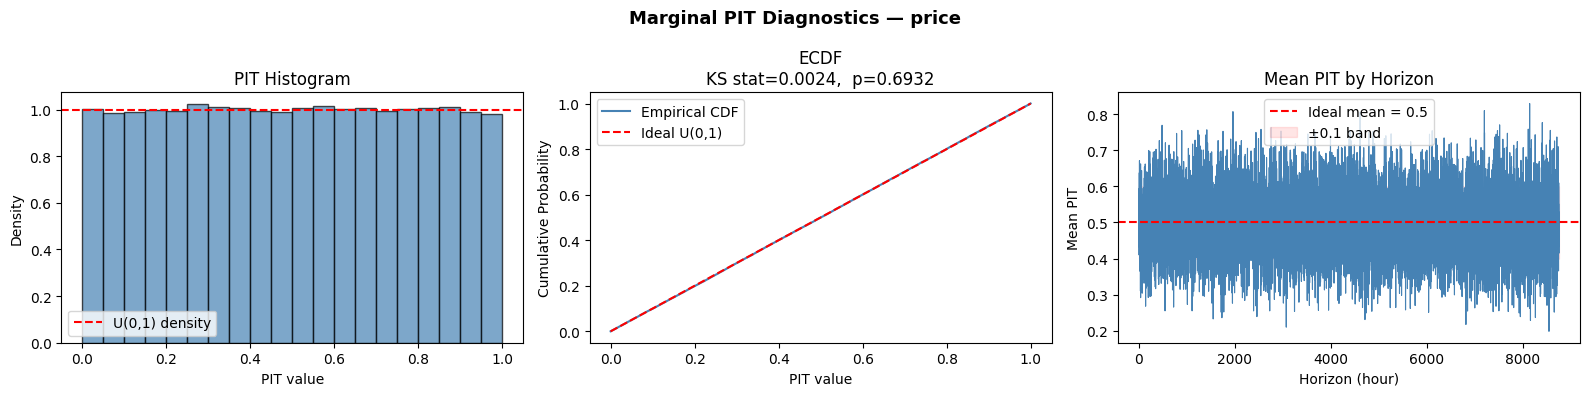

[price] PIT report
  KS statistic:  0.0024
  KS p-value: 0.6932  ✓ do not reject uniformity
  mean:       0.5000  (ideal value 0.5)
  std:        0.2881  (ideal value 0.2887)



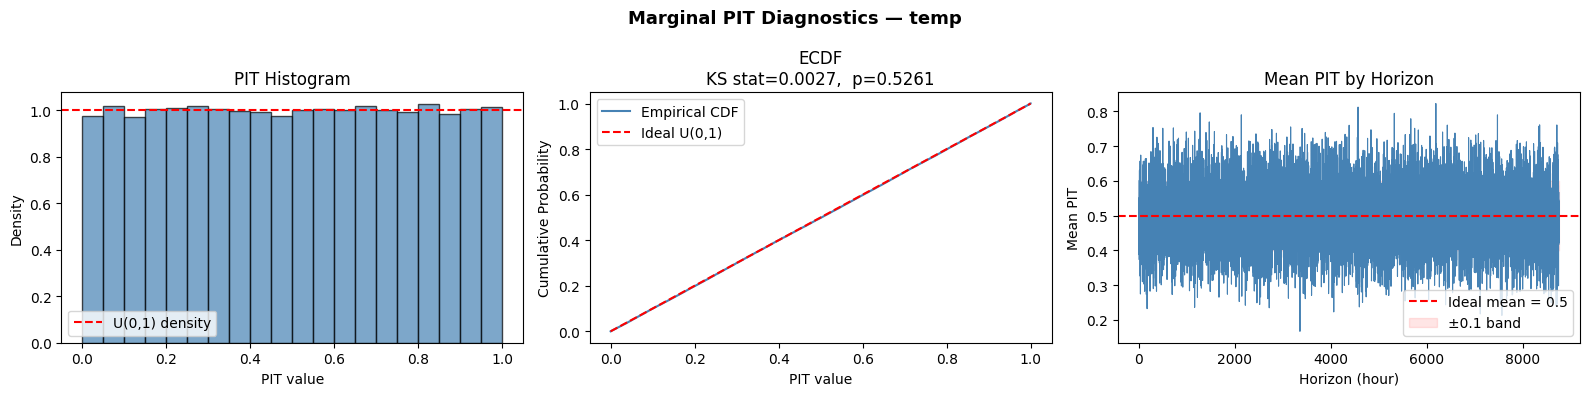

[temp] PIT report
  KS statistic:  0.0027
  KS p-value: 0.5261  ✓ do not reject uniformity
  mean:       0.5011  (ideal value 0.5)
  std:        0.2886  (ideal value 0.2887)



In [ ]:
# ============================================================
# STEP 4: diagnostics plots + KS test
# ============================================================

for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    ks_stat, ks_p = stats.kstest(pit_flat, 'uniform') 

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Marginal PIT Diagnostics — {s}", fontsize=13, fontweight='bold')

    # --- plot 1: Histogram ---
    axes[0].hist(pit_flat, bins=20, edgecolor='k', density=True, alpha=0.7, color='steelblue')
    axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='U(0,1) density')
    axes[0].set_title("PIT Histogram")
    axes[0].set_xlabel("PIT value")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # --- plot 2: ECDF ---
    pit_sorted = np.sort(pit_flat)
    n = len(pit_sorted)
    axes[1].step(pit_sorted, np.arange(1, n + 1) / n, where='post',
                 color='steelblue', label='Empirical CDF')
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Ideal U(0,1)')
    axes[1].set_title(f"ECDF\nKS stat={ks_stat:.4f},  p={ks_p:.4f}")
    axes[1].set_xlabel("PIT value")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend()

    # --- plot 3: every Horizon  PIT mean ---
    pit_mean_by_horizon = pit_dict[s].mean(axis=0).astype(float)
    axes[2].plot(pit_dict[s].columns, pit_mean_by_horizon, color='steelblue', linewidth=0.8) 
    axes[2].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Ideal mean = 0.5')
    axes[2].fill_between(pit_dict[s].columns, 0.4, 0.6, alpha=0.1, color='red', label='±0.1 band')
    axes[2].set_title("Mean PIT by Horizon")
    axes[2].set_xlabel("Horizon (hour)")
    axes[2].set_ylabel("Mean PIT")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # --- conclusion ---
    print(f"{'='*45}")
    print(f"[{s}] PIT report")
    print(f"  KS statistic:  {ks_stat:.4f}")
    print(f"  KS p-value: {ks_p:.4f}  {'✓ do not reject uniformity' if ks_p > 0.05 else '✗ reject uniformity'}")
    print(f"  mean:       {pit_flat.mean():.4f}  (ideal value 0.5)")
    print(f"  std:        {pit_flat.std():.4f}  (ideal value {1/np.sqrt(12):.4f})")
    print(f"{'='*45}\n")

In [25]:
from scipy.stats import anderson, norm

# ============================================================
# STEP 5: Anderson-Darling Test for Uniformity on Gaussianized PIT
# ============================================================

for s in series_names:
    pit_flat = pit_dict[s].values.flatten().astype(float)
    pit_flat = pit_flat[~np.isnan(pit_flat)]  # Remove NaN if any
    
    if len(pit_flat) < 10:  # AD need sufficient samples
        print(f"[{s}] samll sample size ({len(pit_flat)})，no AD test")
        continue
    
   
    # extreme PIT Value can lead to inf/nan after transformation, so we clip them to a reasonable range
    pit_clipped = np.clip(pit_flat, 1e-6, 1 - 1e-6)
    z = norm.ppf(pit_clipped)
    
    # AD test for normality on transformed values
    ad_result = anderson(z, dist='norm')
    
    print(f"{'='*60}")
    print(f"[{s}] Anderson-Darling Test for Uniformity (on Gaussianized PIT)")
    print(f" AD statistic: {ad_result.statistic:.4f}")
    print(f" sample(valide): {len(z)}")
    print()
    print(f" {'significance':<12} {'critical value':<12} {'conclusion'}")
    print(f" {'-'*45}")
    for sig, cv in zip(ad_result.significance_level, ad_result.critical_values):
        reject = ad_result.statistic > cv
        conclusion = "✗ reject uniformity (after transform)" if reject else "✓ do not reject uniformity"
        print(f" {sig:<12.1f} {cv:<12.4f} {conclusion}")
    print(f"{'='*60}\n")

[price] Anderson-Darling Test for Uniformity (on Gaussianized PIT)
 AD statistic: 0.2269
 sample(valide): 87600

 significance critical value conclusion
 ---------------------------------------------
 15.0         0.5760       ✓ do not reject uniformity
 10.0         0.6560       ✓ do not reject uniformity
 5.0          0.7870       ✓ do not reject uniformity
 2.5          0.9180       ✓ do not reject uniformity
 1.0          1.0920       ✓ do not reject uniformity

[temp] Anderson-Darling Test for Uniformity (on Gaussianized PIT)
 AD statistic: 0.3014
 sample(valide): 87600

 significance critical value conclusion
 ---------------------------------------------
 15.0         0.5760       ✓ do not reject uniformity
 10.0         0.6560       ✓ do not reject uniformity
 5.0          0.7870       ✓ do not reject uniformity
 2.5          0.9180       ✓ do not reject uniformity
 1.0          1.0920       ✓ do not reject uniformity



In [ ]:
# ============================================================
# STEP 5.2: Bucket-wise PIT Diagnostics
# ============================================================

buckets = {
    "Intraday":  (1, 24),
    "Weekly":    (25, 168),
    "Monthly":   (169, 720),
    "Long-term": (721, 8760),
}

for s in series_names:
    print(f"\n{'='*72}")
    print(f"[{s}] Bucket-wise PIT Diagnostics")
    print(f"{'='*72}")
    print(f"  {'Bucket':<12} {'n':>7} {'mean':>8} {'std':>8} {'KS stat':>10} {'KS p':>10} {'AD stat':>10}")
    print(f"  {'-'*72}")

    pit_df = pit_dict[s].copy()  # shape: (10, 8760), columns should be horizon index 1..8760
    pit_df.columns = pit_df.columns.astype(int)

    for bucket_name, (h_lo, h_hi) in buckets.items():
        # Select horizons in this bucket
        cols = [h for h in pit_df.columns if h_lo <= h <= h_hi]
        pit_bucket = pit_df[cols].to_numpy().ravel().astype(float)
        pit_bucket = pit_bucket[~np.isnan(pit_bucket)]

        # Summary stats
        n = len(pit_bucket)
        mean = pit_bucket.mean()
        std = pit_bucket.std(ddof=1)

        # KS test against Uniform(0,1)
        ks_stat, ks_p = stats.kstest(pit_bucket, 'uniform')

        # AD diagnostic on Gaussianized PIT
        pit_clipped = np.clip(pit_bucket, 1e-6, 1 - 1e-6)
        z = norm.ppf(pit_clipped)
        ad_result = anderson(z, dist='norm')
        ad_stat = ad_result.statistic

        print(f"  {bucket_name:<12} {n:>7} {mean:>8.4f} {std:>8.4f} {ks_stat:>10.4f} {ks_p:>10.4f} {ad_stat:>10.4f}")

    print(f"  {'-'*72}")
    print("  (Diagnostic only; dependence and horizon heterogeneity within buckets are not formally corrected.)")


In [ ]:
# ============================================================
# STEP 6: Ljung-Box Test on PIT
# ============================================================

from scipy.stats import norm
from statsmodels.stats.diagnostic import acorr_ljungbox

lags_to_test = [24, 168, 720]
eps          = 1e-6
alpha        = 0.05
min_obs      = lags_to_test[-1] + 10  # at least 730 valid observations to test up to lag 720

lb_results = {s: [] for s in series_names}

for s in series_names:
    print(f"\n{'='*65}")
    print(f"[{s}] Ljung-Box Test on Gaussianized PIT (primary)")
    print(f"     and raw PIT (robustness check)")
    print(f"     Note: diagnostic evidence only;")
    print(f"     multiple tests reported without family-wise error control.")
    print(f"{'='*65}")

    for asof in asof_dates:

        # --- 1. Take the PIT sequence and remove non-finite values. ---
        pit_seq = pit_dict[s].loc[asof].values.astype(float) 
        mask    = np.isfinite(pit_seq) # Remove non-finite values (if any)
        pit_seq = pit_seq[mask]

        if len(pit_seq) < min_obs: 
            print(f"\n  as-of: {asof.date()} — Skip (Insufficient effective sample size:) {len(pit_seq)}）") # defensive check
            continue

        # --- 2. Construct a sequence (using the same clip only once).--- transformed using the inverse standard normal CDF, after clipping to (ε,1−ε)
        pit_clip = np.clip(pit_seq, eps, 1 - eps)
        z        = norm.ppf(pit_clip)   # primary：Gaussianized PIT
        pit_raw  = pit_clip             # PIT on original scale (clipped for numerical stability)


        # --- 3. compute lag ---
        lb_z_all   = acorr_ljungbox(z,       lags=lags_to_test, return_df=True) # primary test on Gaussianized PIT
        lb_pit_all = acorr_ljungbox(pit_raw, lags=lags_to_test, return_df=True) # robustness check on raw PIT

        print(f"\n  as-of: {asof.date()}  (n={len(pit_seq)})")
        print(f"  {'Lag (up to m)':<16} {'LB stat (z)':<14} {'p (z)':<12} {'p (PIT raw)':<14} {'conclusion'}")
        print(f"  {'-'*68}")

        for i, lag in enumerate(lags_to_test):
            # iloc to avoid version compatibility issues
            stat_z = lb_z_all['lb_stat'].iloc[i]
            p_z    = lb_z_all['lb_pvalue'].iloc[i]
            p_pit  = lb_pit_all['lb_pvalue'].iloc[i]

            reject     = p_z < alpha
            conclusion = "✗ Serial dependence" if reject else "✓ No serial dependence"

            print(f"  m={lag:<13} {stat_z:<14.4f} {p_z:<12.4f} {p_pit:<14.4f} {conclusion}")

            lb_results[s].append({
                'asof':      asof,
                'lag':       lag,
                'n_obs':     len(pit_seq),
                'lb_stat_z': stat_z,
                'p_z':       p_z,
                'p_pit':     p_pit,
                'reject_z':  reject
            })

# --- 4.  DataFrame ---
lb_results_df = {s: pd.DataFrame(lb_results[s]) for s in series_names}

# --- 5. report ---
print(f"\n{'='*65}")
print(f"Summary: Rejection rate across as-of dates (α={alpha})")
print(f"{'='*65}")
print(f"  {'Series':<10} {'Lag (up to m)':<16} {'Rejection Rate'}")
print(f"  {'-'*50}")

for s in series_names:
    df = lb_results_df[s]
    for lag in lags_to_test:
        subset = df[df['lag'] == lag]

        # empty subset
        if len(subset) == 0:
            print(f"  {s:<10} m={lag:<13} N/A (no valid as-of dates)") 
            continue

        reject_rate = subset['reject_z'].mean()
        n_reject    = subset['reject_z'].sum()
        n_total     = len(subset)
        print(f"  {s:<10} m={lag:<13} {reject_rate:.1%}  ({n_reject}/{n_total} as-of dates)")


[price] Ljung-Box Test on Gaussianized PIT (primary)
     and raw PIT (robustness check)
     Note: diagnostic evidence only;
     multiple tests reported without family-wise error control.

  as-of: 2020-01-01  (n=8760)
  Lag (up to m)    LB stat (z)    p (z)        p (PIT raw)    conclusion
  --------------------------------------------------------------------
  m=24            22.2754        0.5628       0.4923         ✓ No serial dependence
  m=168           171.2053       0.4168       0.1345         ✓ No serial dependence
  m=720           728.1560       0.4084       0.3434         ✓ No serial dependence

  as-of: 2020-01-02  (n=8760)
  Lag (up to m)    LB stat (z)    p (z)        p (PIT raw)    conclusion
  --------------------------------------------------------------------
  m=24            26.1531        0.3454       0.4022         ✓ No serial dependence
  m=168           159.1643       0.6752       0.7084         ✓ No serial dependence
  m=720           666.6799       0.9227

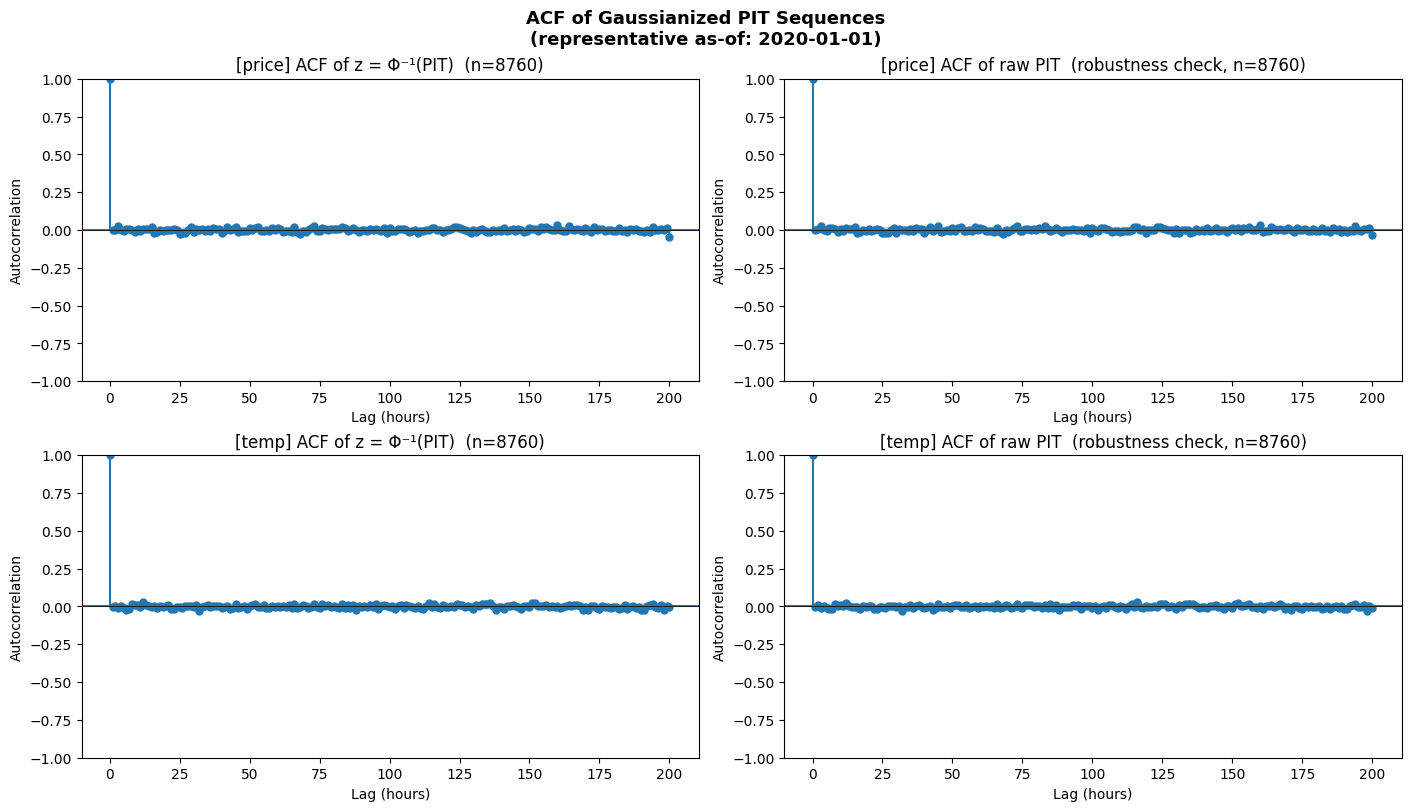

In [33]:
# ============================================================
# ACF of Gaussianized PIT Sequences
# ============================================================

import numpy as np
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# dynamic subplots based on number of series
n_series = len(series_names)
fig, axes = plt.subplots(
    n_series, 2,
    figsize=(14, 4 * n_series),
    constrained_layout=True      
)

# axes is 1D if n_series=1, so we ensure it's always 2D for consistent indexing
if n_series == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    "ACF of Gaussianized PIT Sequences\n"
    f"(representative as-of: {asof_dates[0].date()})",
    fontsize=13, fontweight='bold'
)

# choose the present asof date
asof = asof_dates[0]

for idx, s in enumerate(series_names):

    # ---  PIT sequence ---
    pit_seq  = pit_dict[s].loc[asof].values.astype(float)

    # --- Gaussianized PIT---
    pit_clip = np.clip(pit_seq, 1e-6, 1 - 1e-6)
    z        = norm.ppf(pit_clip)

    # NaN/inf can arise from extreme PIT values, so we filter them out for ACF plotting
    mask_z = np.isfinite(z)
    z      = z[mask_z]

    # --- Raw PIT（robustness check）---
    pit_raw      = pit_clip.copy()
    mask_pit     = np.isfinite(pit_raw)
    pit_raw      = pit_raw[mask_pit]

    # --- Gaussianized PIT ---
    plot_acf(
        z, lags=200, alpha=0.05,
        ax=axes[idx, 0],
        title=f"[{s}] ACF of z = Φ⁻¹(PIT)  "
              f"(n={len(z)})"
    )
    axes[idx, 0].set_xlabel("Lag (hours)")
    axes[idx, 0].set_ylabel("Autocorrelation")
    axes[idx, 0].axhline(0, color='black', linewidth=0.5)

    # --- Raw PIT（robustness）---
    plot_acf(
        pit_raw, lags=200, alpha=0.05,
        ax=axes[idx, 1],
        title=f"[{s}] ACF of raw PIT  "
              f"(robustness check, n={len(pit_raw)})"
    )
    axes[idx, 1].set_xlabel("Lag (hours)")
    axes[idx, 1].set_ylabel("Autocorrelation")
    axes[idx, 1].axhline(0, color='black', linewidth=0.5)

plt.show()

In [ ]:
# ============================================================
# The μ/σ normalization of pooled simulated draws is used to give price and temp a fixed, model-inherent, 
# and consistent distance scale across as-of parameters, making the Energy Score comparable across different prediction windows.
# ============================================================

all_price_sims = np.concatenate([
    sims_dict[asof]['price'].values.flatten()
    for asof in asof_dates
])
all_temp_sims = np.concatenate([
    sims_dict[asof]['temp'].values.flatten()
    for asof in asof_dates
])

mu_price  = float(np.mean(all_price_sims))
std_price = float(np.std(all_price_sims))
mu_temp   = float(np.mean(all_temp_sims))
std_temp  = float(np.std(all_temp_sims))

print(f"Standardization params (from pooled simulated draws):")
print(f"  price: μ={mu_price:.4f}, σ={std_price:.4f}")
print(f"  temp:  μ={mu_temp:.4f},  σ={std_temp:.4f}")

Standardization params (from pooled simulated draws):
  price: μ=50.0002, σ=8.4555
  temp:  μ=9.9998,  σ=10.6301


In [ ]:
# ============================================================
# STEP 8: Energy Score implementation
# ============================================================


# --- 8.2 core function ---
def energy_score(sims_price, sims_temp, real_price, real_temp,  
                 mu_p, std_p, mu_t, std_t,
                 M=500, R=5, seed=42):
    """
    Joint Energy Score for bivariate path forecasts.

    The joint forecast vector is defined as:
        x = (x^price_{1:H}, x^temp_{1:H}) ∈ R^{2H}
    Vectorization order is arbitrary under Euclidean norm.

    Standardization
    ---------------
    Both variables are standardized using parameters computed from
    a fixed reference set (pooled simulated draws across all as-of
    dates), ensuring scale comparability across evaluation windows
    and preventing the distance metric from being dominated by
    differences in variable units or magnitudes.

    Term 1 & Term 2
    ---------------
    Term 1 : E||X - y||
             Estimated using all N simulation paths.
    Term 2 : (1/2)E||X - X'||
             Approximated via repeated subsampling to reduce O(N²)
             complexity. Off-diagonal U-statistic on M subsampled
             paths (upper triangle only), repeated R times;
             final estimate is the mean over R runs.

    Parameters
    ----------
    sims_price : (H, N) — simulated paths, price
    sims_temp  : (H, N) — simulated paths, temp
    real_price : (H,)   — realized values, price
    real_temp  : (H,)   — realized values, temp
    mu_p, std_p: float  — standardization params (pooled sims)
    mu_t, std_t: float  — standardization params (pooled sims)
    M          : int    — subsample size for term 2 (default 500)
    R          : int    — MC repetitions for term 2 (default 5)
    seed       : int    — random seed for reproducibility

    Returns
    -------
    es     : float — Energy Score (lower is better;
                     not guaranteed positive)
    term1  : float — E||X - y|| (forecast accuracy)
    term2  : float — (1/2)E||X - X'|| (sharpness penalty)
    """

    if std_p <= 0:
        raise ValueError(f"std_p must be positive, got {std_p}")
    if std_t <= 0:
        raise ValueError(f"std_t must be positive, got {std_t}")
    if not np.isfinite(sims_price).all():
        raise ValueError("non-finite values in sims_price")
    if not np.isfinite(sims_temp).all():
        raise ValueError("non-finite values in sims_temp")
    if not np.isfinite(real_price).all():
        raise ValueError("non-finite values in real_price")
    if not np.isfinite(real_temp).all():
        raise ValueError("non-finite values in real_temp")

    H, N = sims_price.shape

    if sims_temp.shape != (H, N):
        raise ValueError(
            f"sims_temp shape {sims_temp.shape} != sims_price shape {(H, N)}")
    if real_price.shape != (H,):
        raise ValueError(
            f"real_price shape {real_price.shape} != ({H},)")
    if real_temp.shape != (H,):
        raise ValueError(
            f"real_temp shape {real_temp.shape} != ({H},)")
    if M > N:
        raise ValueError(f"M={M} cannot exceed N={N}")

    rng = np.random.default_rng(seed)

    # --- normalize + float32 ---
    y_price = ((real_price - mu_p) / std_p).astype(np.float32) 
    y_temp  = ((real_temp  - mu_t) / std_t).astype(np.float32)
    y_flat  = np.concatenate([y_price, y_temp])           # (2H,)

    x_price = ((sims_price - mu_p) / std_p).astype(np.float32)
    x_temp  = ((sims_temp  - mu_t) / std_t).astype(np.float32)
    X_flat  = np.concatenate(
                  [x_price, x_temp], axis=0).T            # (N, 2H)

    # --- Term 1：E||X - y||，all path ---
    diff1  = X_flat - y_flat[None, :]                     # (N, 2H)
    norm1  = np.linalg.norm(diff1, axis=1)                # (N,)
    term1  = float(norm1.mean())

    # --- Term 2：(1/2)E||X - X'||
    #     U-statistic（off-diagonal）
    tri        = np.triu_indices(M, k=1)  # upper triangle indices for M paths
    term2_runs = []

    for r in range(R):
        idx   = rng.choice(N, size=M, replace=False) # subsample M paths without replacement
        X_sub = X_flat[idx]                               # (M, 2H)

        # ||xi - xj||² = ||xi||² + ||xj||² - 2<xi,xj>. i< j terms are zeroed out by using only upper triangle indices
        sq      = np.sum(X_sub**2, axis=1)                # (M,)
        dist_sq = (sq[:, None] + sq[None, :]
                   - 2.0 * (X_sub @ X_sub.T))             # (M, M)
        dist_sq = np.clip(dist_sq, 0.0, None)             # numerical stability
        norm2   = np.sqrt(dist_sq)                        # (M, M)

        term2_runs.append(0.5 * float(norm2[tri].mean()))  # mean over upper triangle pairs.  

    term2 = float(np.mean(term2_runs)) # mean over R runs
    es    = term1 - term2

    return es, term1, term2


# --- single points ---
asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

es_val, t1, t2 = energy_score(
    sims_p, sims_t, real_p, real_t,
    mu_price, std_price, mu_temp, std_temp,
    M=500, R=5, seed=42
)

print(f"\n=== Single as-of ES Validation ===")
print(f"as-of date  : {asof_test.date()}")
print(f"Joint dim   : {sims_p.shape[0] * 2}  "
      f"(H={sims_p.shape[0]}, 2 variables)")
print(f"N paths     : {sims_p.shape[1]}")
print(f"M subsample : 500,  R repetitions : 5")
print(f"")
print(f"Term 1  E||X-y||      : {t1:.6f}")
print(f"Term 2  E||X-X'||/2   : {t2:.6f}")
print(f"Energy Score          : {es_val:.6f}")
print(f"Term2 / Term1 ratio   : {t2/t1:.4f}")


=== Single as-of ES Validation ===
as-of date  : 2020-01-01
Joint dim   : 17520  (H=8760, 2 variables)
N paths     : 5000
M subsample : 500,  R repetitions : 5

Term 1  E||X-y||      : 86.090721
Term 2  E||X-X'||/2   : 43.365731
Energy Score          : 42.724990
Term2 / Term1 ratio   : 0.5037


In [31]:
# ============================================================
# STEP 9: Energy Score — on 10 as-of dates, full joint evaluation
# ============================================================

import time

es_results = []

print(f"Computing Full Joint Energy Score (dim={8760*2})...")
print(f"M=500, R=5, N=5000")
print(f"Note: fixed seed=42 across all as-of dates to ensure")
print(f"      subsampling noise does not confound cross-date comparison")
print(f"{'='*60}")

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    es_val, t1, t2 = energy_score(
        sims_p, sims_t, real_p, real_t,
        mu_price, std_price, mu_temp, std_temp,
        M=500, R=5, seed=42          # fixed seed for reproducibility across as-of dates
    )

    t_elapsed = time.time() - t_start

    # defensive check to avoid division by zero in ratio calculation
    ratio = t2 / t1 if t1 > 0 else np.nan

    es_results.append({
        'asof':    asof,
        'es_date': asof.date(),      
        'es':      es_val,
        'term1':   t1,
        'term2':   t2,
        't2_t1':   ratio,
        'time_s':  t_elapsed
    })

    print(f"  {asof.date()}  ES={es_val:.4f}  "
          f"T1={t1:.4f}  T2={t2:.4f}  "
          f"ratio={ratio:.4f}  ({t_elapsed:.1f}s)")

# ---  DataFrame ---
es_df = pd.DataFrame(es_results)

# --- Sanity check：ES = Term1 - Term2 ---
max_discrepancy = np.max(
    np.abs(es_df['es'] - (es_df['term1'] - es_df['term2']))
)
print(f"\nSanity check  max|ES - (T1-T2)| = {max_discrepancy:.2e}  "
      f"{'✓ OK' if max_discrepancy < 1e-6 else '✗ CHECK NEEDED'}")

# --- report summary ---
print(f"\n{'='*60}")
print(f"Summary: Full Joint Energy Score across as-of dates")
print(f"{'='*60}")
print(f"  Mean ES   : {es_df['es'].mean():.4f}")
print(f"  Std  ES   : {es_df['es'].std():.4f}")
print(f"  Min  ES   : {es_df['es'].min():.4f}  "
      f"({es_df.loc[es_df['es'].idxmin(), 'es_date']})")
print(f"  Max  ES   : {es_df['es'].max():.4f}  "
      f"({es_df.loc[es_df['es'].idxmax(), 'es_date']})")
print(f"  Mean T2/T1: {es_df['t2_t1'].mean():.4f}")
print(f"  Total time: {es_df['time_s'].sum():.1f}s  "
      f"({es_df['time_s'].sum()/60:.1f} min)")

Computing Full Joint Energy Score (dim=17520)...
M=500, R=5, N=5000
Note: fixed seed=42 across all as-of dates to ensure
      subsampling noise does not confound cross-date comparison
  2020-01-01  ES=42.7250  T1=86.0907  T2=43.3657  ratio=0.5037  (4.9s)
  2020-01-02  ES=44.0811  T1=87.4389  T2=43.3577  ratio=0.4959  (4.0s)
  2020-01-03  ES=42.7414  T1=86.1085  T2=43.3671  ratio=0.5036  (3.9s)
  2020-01-04  ES=43.2985  T1=86.6633  T2=43.3648  ratio=0.5004  (3.9s)
  2020-01-05  ES=43.6669  T1=87.0149  T2=43.3480  ratio=0.4982  (3.8s)
  2020-01-06  ES=43.2262  T1=86.5922  T2=43.3659  ratio=0.5008  (5.4s)
  2020-01-07  ES=43.4666  T1=86.8241  T2=43.3575  ratio=0.4994  (4.1s)
  2020-01-08  ES=43.0865  T1=86.4438  T2=43.3574  ratio=0.5016  (5.1s)
  2020-01-09  ES=43.1756  T1=86.5362  T2=43.3606  ratio=0.5011  (4.8s)
  2020-01-10  ES=43.1735  T1=86.5350  T2=43.3614  ratio=0.5011  (8.1s)

Sanity check  max|ES - (T1-T2)| = 0.00e+00  ✓ OK

Summary: Full Joint Energy Score across as-of dates
  

ES across as-of is highly stable (Std 0.41, <1% relative variability), indicating consistent joint forecast quality across forecast origins under the benchmark setting.

The dispersion penalty term (term2) is nearly constant across as-of dates, while most variation arises from the data-fit term (term1), consistent with fixed standardization and stationary simulation dynamics.

The identity ES = term1 − term2 holds up to machine precision, confirming correct implementation.


this is benchmark sanity check：Because realized outcomes are generated under the same distributional assumptions as the simulations, this experiment primarily validates the implementation and provides a baseline reference for later misspecification stress tests

In [32]:
# ============================================================
# Appendix: Seed Sensitivity Analysis for Energy Score
# ============================================================

seeds_to_test = [1, 7, 42, 99, 2024]
es_seed_results = {}

for seed_val in seeds_to_test:
    es_seed_results[seed_val] = []

    for asof in asof_dates:
        sims_p = sims_dict[asof]['price'].values
        sims_t = sims_dict[asof]['temp'].values
        real_p = realized_dict['price'].loc[asof].values
        real_t = realized_dict['temp'].loc[asof].values

        es_val, _, _ = energy_score(
            sims_p, sims_t, real_p, real_t,
            mu_price, std_price, mu_temp, std_temp,
            M=500, R=5, seed=seed_val
        )
        es_seed_results[seed_val].append(es_val)

# every seed summary
print(f"{'='*55}")
print(f"Seed Sensitivity: Mean ES across as-of dates")
print(f"{'='*55}")
print(f"  {'Seed':<10} {'Mean ES':<12} {'Std ES':<12}")
print(f"  {'-'*35}")

for seed_val, es_list in es_seed_results.items():
    print(f"  {seed_val:<10} {np.mean(es_list):<12.4f} "
          f"{np.std(es_list):<12.4f}")

# rank robustness check across seeds
import pandas as pd
es_seed_df = pd.DataFrame(es_seed_results, index=asof_dates)
rank_df = es_seed_df.rank()

print(f"\nRank correlation across seeds (Spearman):")
print(rank_df.corr(method='spearman').round(3))

Seed Sensitivity: Mean ES across as-of dates
  Seed       Mean ES      Std ES      
  -----------------------------------
  1          43.2649      0.3817      
  7          43.2652      0.3813      
  42         43.2641      0.3853      
  99         43.2654      0.3809      
  2024       43.2650      0.3836      

Rank correlation across seeds (Spearman):
       1      7      42     99     2024
1     1.000  1.000  1.000  0.988  1.000
7     1.000  1.000  1.000  0.988  1.000
42    1.000  1.000  1.000  0.988  1.000
99    0.988  0.988  0.988  1.000  0.988
2024  1.000  1.000  1.000  0.988  1.000


In [34]:
# ============================================================
# STEP 10: Lag-restricted Variogram Score
# setup: lag sets, β, and weight design
# ============================================================

lags_main   = [1, 2, 6, 12, 24, 48, 168]
lags_robust = [720]
beta_main   = 0.5
beta_sens   = 1.0

# main weight w_l ∝ 1/l
w_raw  = np.array([1.0 / l for l in lags_main],dtype=float)
w_norm = w_raw / w_raw.sum()

# ---- robustness weight (single lag) ----
w_robust = np.array([1.0], dtype=float)

assert np.isclose(w_norm.sum(), 1.0, atol=1e-12)

print("Design Summary")
print(f"{'='*50}")
print(f"Lag set (main)   : {lags_main}")
print(f"Lag set (robust) : {lags_robust}")
print(f"β (main)         : {beta_main}")
print(f"β (sensitivity)  : {beta_sens}")
print()
print(f"{'Lag':<8} {'w_raw':<14} {'w_normalized'}")
print(f"{'-'*35}")
for l, wr, wn in zip(lags_main, w_raw, w_norm):
    print(f"{l:<8} {wr:<14.6f} {wn:.6f}")
print(f"Sum of weights   : {w_norm.sum():.10f}")

Design Summary
Lag set (main)   : [1, 2, 6, 12, 24, 48, 168]
Lag set (robust) : [720]
β (main)         : 0.5
β (sensitivity)  : 1.0

Lag      w_raw          w_normalized
-----------------------------------
1        1.000000       0.549918
2        0.500000       0.274959
6        0.166667       0.091653
12       0.083333       0.045827
24       0.041667       0.022913
48       0.020833       0.011457
168      0.005952       0.003273
Sum of weights   : 1.0000000000


In [35]:
# ============================================================
# STEP 10: Lag-restricted Variogram Score
# Core Function 
# ============================================================

import numpy as np
import warnings

def lag_variogram_score(sims, realized, lags, weights, beta,
                        check_finite=False):
    """
    Lag-restricted Variogram Score for a univariate series.

    For each lag l in lags, computes:
        VS_l = mean_t [ |y_t - y_{t-l}|^beta - E|X_t - X_{t-l}|^beta ]^2

    The total score is the weighted sum:
        VS = sum_l w_l * VS_l

    Lower values indicate better temporal dependence calibration.

    Parameters
    ----------
    sims         : array-like, shape (H, N)
                   Simulated paths (H horizons, N paths)
    realized     : array-like, shape (H,)
                   Realized values
    lags         : list of int
                   Lag values in L (must be positive)
    weights      : array-like, shape (len(lags),)
                   Normalized weights (must sum to 1, all non-negative)
    beta         : float
                   Power parameter, must be in (0, 2)
    check_finite : bool, optional (default=False)
                   If True, check sims and realized for NaN/inf.
                   Recommended for single-point validation;
                   disable for full runs to avoid overhead.

    Returns
    -------
    vs_total  : float
                Weighted variogram score (lower is better)
    vs_by_lag : dict
                Per-lag breakdown with keys:
                lag_score, weight, contribution, n_pairs
    """

    # --- Type coercion ---
    sims     = np.asarray(sims,     dtype=float)
    realized = np.asarray(realized, dtype=float)
    weights  = np.asarray(weights,  dtype=float)

    # --- Shape checks ---
    if sims.ndim != 2:
        raise ValueError(
            f"sims must be 2D (H, N), got shape {sims.shape}")

    if realized.ndim != 1:
        raise ValueError(
            f"realized must be 1D, got shape {realized.shape}")

    H, N = sims.shape

    if realized.shape[0] != H:
        raise ValueError(
            f"realized length {realized.shape[0]} != sims H {H}")

    # --- Parameter checks ---
    if not (0.0 < beta < 2.0):
        raise ValueError(
            f"beta must be in (0, 2), got {beta}")

    if len(weights) != len(lags):
        raise ValueError(
            f"weights length {len(weights)} != lags length {len(lags)}")

    if np.any(weights < 0):
        raise ValueError(
            "weights must be non-negative")

    if not np.isclose(weights.sum(), 1.0, atol=1e-12):
        raise ValueError(
            f"weights must sum to 1, got {weights.sum():.10f}")

    # --- Optional finite check (single-point validation only) ---
    if check_finite:
        if not np.isfinite(sims).all():
            raise ValueError("non-finite values in sims")
        if not np.isfinite(realized).all():
            raise ValueError("non-finite values in realized")

    # --- Main computation ---
    vs_total  = 0.0
    vs_by_lag = {}

    for l, w_l in zip(lags, weights):

        if l <= 0:
            raise ValueError(
                f"lags must be positive integers, got {l}")

        if l >= H:
            warnings.warn(
                f"lag={l} >= H={H}; skipping this lag.")
            continue

        # Realized increments: |y_t - y_{t-l}|^beta, shape (H-l,)
        real_diff = np.abs(realized[l:] - realized[:-l]) ** beta 

        # Simulated increments: |X_t - X_{t-l}|^beta, shape (H-l, N)
        sim_diff  = np.abs(sims[l:, :] - sims[:-l, :]) ** beta

        # Layer 1: average over N paths -> E_F|X_t - X_{t-l}|^beta
        # shape: (H-l,)
        sim_mean  = sim_diff.mean(axis=1)

        # Layer 2: average squared error over valid time points
        # shape: scalar
        lag_score = ((real_diff - sim_mean) ** 2).mean()

        # Weighted accumulation
        vs_total    += w_l * lag_score
        vs_by_lag[l] = {
            "lag_score":    float(lag_score),
            "weight":       float(w_l),
            "contribution": float(w_l * lag_score),
            "n_pairs":      int(H - l)
        }

    return float(vs_total), vs_by_lag

In [36]:
# ============================================================
# STEP 10: Single-point Validation with detailed per-lag breakdown
# ============================================================

asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

# Run with check_finite=True for single-point validation
vs_p, vs_p_by_lag = lag_variogram_score(
    sims_p, real_p, lags_main, w_norm,
    beta=beta_main, check_finite=True
)
vs_t, vs_t_by_lag = lag_variogram_score(
    sims_t, real_t, lags_main, w_norm,
    beta=beta_main, check_finite=True
)
vs_total = 0.5 * (vs_p + vs_t)

# --- Per-lag breakdown ---
print("="*70)
print(f"Single as-of Validation: {asof_test.date()},  β={beta_main}")
print("Note: lower values indicate better temporal dependence calibration")
print("="*70)
print(f"  {'Lag':<8} {'n_pairs':<10} {'weight':<10} "
      f"{'VS_price':<14} {'VS_temp':<14} {'Contribution'}")
print("-"*70)

# Iterate over keys actually computed (safe against skipped lags)
for l in vs_p_by_lag.keys():
    p       = vs_p_by_lag[l]
    t       = vs_t_by_lag[l]
    contrib = 0.5 * (p['contribution'] + t['contribution'])
    print(f"  {l:<8} {p['n_pairs']:<10} {p['weight']:<10.4f} "
          f"{p['lag_score']:<14.6f} {t['lag_score']:<14.6f} "
          f"{contrib:.6f}")

print()
print(f"  VS_price : {vs_p:.6f}")
print(f"  VS_temp  : {vs_t:.6f}")
print(f"  VS_total : {vs_total:.6f}  "
      f"(simple mean of price and temp)")

# --- Sanity check ---
vs_p_manual = sum(
    vs_p_by_lag[l]['contribution']
    for l in vs_p_by_lag.keys()
)
vs_t_manual = sum(
    vs_t_by_lag[l]['contribution']
    for l in vs_t_by_lag.keys()
)
vs_total_manual = 0.5 * vs_p_manual + 0.5 * vs_t_manual

print()
print("Sanity checks:")
print(f"  |VS_price - sum(contributions)|  = "
      f"{abs(vs_p - vs_p_manual):.2e}")
print(f"  |VS_temp  - sum(contributions)|  = "
      f"{abs(vs_t - vs_t_manual):.2e}")
print(f"  |VS_total - manual reconstruction| = "
      f"{abs(vs_total - vs_total_manual):.2e}")

Single as-of Validation: 2020-01-01,  β=0.5
Note: lower values indicate better temporal dependence calibration
  Lag      n_pairs    weight     VS_price       VS_temp        Contribution
----------------------------------------------------------------------
  1        8759       0.5499     0.865886       0.542904       0.387360
  2        8758       0.2750     0.905742       0.597699       0.206692
  6        8754       0.0917     1.026240       0.577535       0.073495
  12       8748       0.0458     0.975185       0.448848       0.032629
  24       8736       0.0229     0.854238       0.519899       0.015743
  48       8712       0.0115     0.848090       0.530799       0.007899
  168      8592       0.0033     0.835035       0.532350       0.002238

  VS_price : 0.895979
  VS_temp  : 0.556134
  VS_total : 0.726056  (simple mean of price and temp)

Sanity checks:
  |VS_price - sum(contributions)|  = 0.00e+00
  |VS_temp  - sum(contributions)|  = 0.00e+00
  |VS_total - manual reconstru

In [ ]:
# ============================================================
# STEP 10: Full Evaluation — All As-of Dates
# ============================================================

import time

# --- β=0.5 main ---
print("="*65)
print(f"Full Evaluation: all as-of dates  (β={beta_main}, main)")
print("="*65)

vs_results = []

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_main, w_norm,
        beta=beta_main, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_main, w_norm,
        beta=beta_main, check_finite=False
    )
    vs_total  = 0.5 * (vs_p + vs_t)
    t_elapsed = time.time() - t_start

    vs_results.append({
        'asof':     asof,
        'vs_price': vs_p,
        'vs_temp':  vs_t,
        'vs_total': vs_total,
        'time_s':   t_elapsed
    })

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}  "
          f"({t_elapsed:.2f}s)")

vs_df = pd.DataFrame(vs_results)

# --- Summary β=0.5 ---
print()
print("="*65)
print(f"Summary  (β={beta_main})")
print("="*65)
print(f"  {'Metric':<12} {'Mean':<12} {'Std':<12} "
      f"{'Min':<12} {'Max':<12} {'CV (Std/Mean)'}")
print("-"*72)
for col in ['vs_price', 'vs_temp', 'vs_total']:
    mean = vs_df[col].mean()
    std  = vs_df[col].std()
    cv   = std / mean if mean > 0 else np.nan 
    print(f"  {col:<12} {mean:<12.6f} {std:<12.6f} "
          f"{vs_df[col].min():<12.6f} {vs_df[col].max():<12.6f} "
          f"{cv:.4f}")

# Baseline stability check
cv_total = vs_df['vs_total'].std() / vs_df['vs_total'].mean()
print()
if cv_total < 0.05:
    print(f"  Baseline stability: CV={cv_total:.4f} < 0.05  "
          f"✓ stable under correct specification")
else:
    print(f"  Baseline stability: CV={cv_total:.4f} >= 0.05  "
          f"⚠ higher than expected variation")

print(f"\n  Total time: {vs_df['time_s'].sum():.1f}s  "
      f"({vs_df['time_s'].sum()/60:.2f} min)")


# --- β=1.0 sensitivity ---
print()
print("="*65)
print(f"Sensitivity Check  (β={beta_sens})")
print("="*65)

vs_sens_results = []

for asof in asof_dates:

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_main, w_norm,
        beta=beta_sens, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_main, w_norm,
        beta=beta_sens, check_finite=False
    )
    vs_total = 0.5 * (vs_p + vs_t)

    vs_sens_results.append({
        'asof':     asof,
        'vs_price': vs_p,
        'vs_temp':  vs_t,
        'vs_total': vs_total
    })

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}")

vs_sens_df = pd.DataFrame(vs_sens_results)

# --- Summary β=1.0 ---
print()
print("="*65)
print(f"Summary  (β={beta_sens})")
print("="*65)
print(f"  {'Metric':<12} {'Mean':<12} {'Std':<12} "
      f"{'Min':<12} {'Max'}")
print("-"*60)
for col in ['vs_price', 'vs_temp', 'vs_total']:
    print(f"  {col:<12} {vs_sens_df[col].mean():<12.6f} "
          f"{vs_sens_df[col].std():<12.6f} "
          f"{vs_sens_df[col].min():<12.6f} "
          f"{vs_sens_df[col].max():.6f}")

# --- Rank consistency: β=0.5 vs β=1.0 ---
rank_corr = vs_df['vs_total'].rank().corr(
    vs_sens_df['vs_total'].rank(),
    method='spearman'
)
print()
print(f"  Spearman rank correlation (β=0.5 vs β=1.0): "
      f"{rank_corr:.4f}")
if rank_corr >= 0.95:
    print(f"  ✓ Rankings are highly stable across β choices")
else:
    print(f"  ⚠ Rank ordering differs between β choices — "
          f"report both in paper")


# --- Robustness check: lag=720 ---
print()
print("="*65)
print(f"Robustness Check  lag=720  (β={beta_main})")
print("="*65)

w_robust        = np.array([1.0])
vs_robust_list  = []

for asof in asof_dates:

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    vs_p, _ = lag_variogram_score(
        sims_p, real_p, lags_robust, w_robust,
        beta=beta_main, check_finite=False
    )
    vs_t, _ = lag_variogram_score(
        sims_t, real_t, lags_robust, w_robust,
        beta=beta_main, check_finite=False
    )
    vs_total = 0.5 * (vs_p + vs_t)
    vs_robust_list.append(vs_total)

    print(f"  {asof.date()}  "
          f"VS_price={vs_p:.6f}  "
          f"VS_temp={vs_t:.6f}  "
          f"VS_total={vs_total:.6f}")

print()
print(f"  lag=720 summary:")
print(f"  Mean : {np.mean(vs_robust_list):.6f}")
print(f"  Std  : {np.std(vs_robust_list):.6f}")
cv_robust = np.std(vs_robust_list) / np.mean(vs_robust_list)
print(f"  CV   : {cv_robust:.4f}")

Full Evaluation: all as-of dates  (β=0.5, main)
  2020-01-01  VS_price=0.895979  VS_temp=0.556134  VS_total=0.726056  (6.54s)
  2020-01-02  VS_price=0.949430  VS_temp=0.554495  VS_total=0.751963  (4.80s)
  2020-01-03  VS_price=0.902588  VS_temp=0.560319  VS_total=0.731453  (4.67s)
  2020-01-04  VS_price=0.925234  VS_temp=0.554287  VS_total=0.739761  (5.43s)
  2020-01-05  VS_price=0.916888  VS_temp=0.559014  VS_total=0.737951  (6.60s)
  2020-01-06  VS_price=0.906229  VS_temp=0.565547  VS_total=0.735888  (7.07s)
  2020-01-07  VS_price=0.925063  VS_temp=0.559387  VS_total=0.742225  (8.39s)
  2020-01-08  VS_price=0.914911  VS_temp=0.554477  VS_total=0.734694  (6.77s)
  2020-01-09  VS_price=0.923298  VS_temp=0.554540  VS_total=0.738919  (4.43s)
  2020-01-10  VS_price=0.920588  VS_temp=0.559894  VS_total=0.740241  (4.62s)

Summary  (β=0.5)
  Metric       Mean         Std          Min          Max          CV (Std/Mean)
------------------------------------------------------------------------


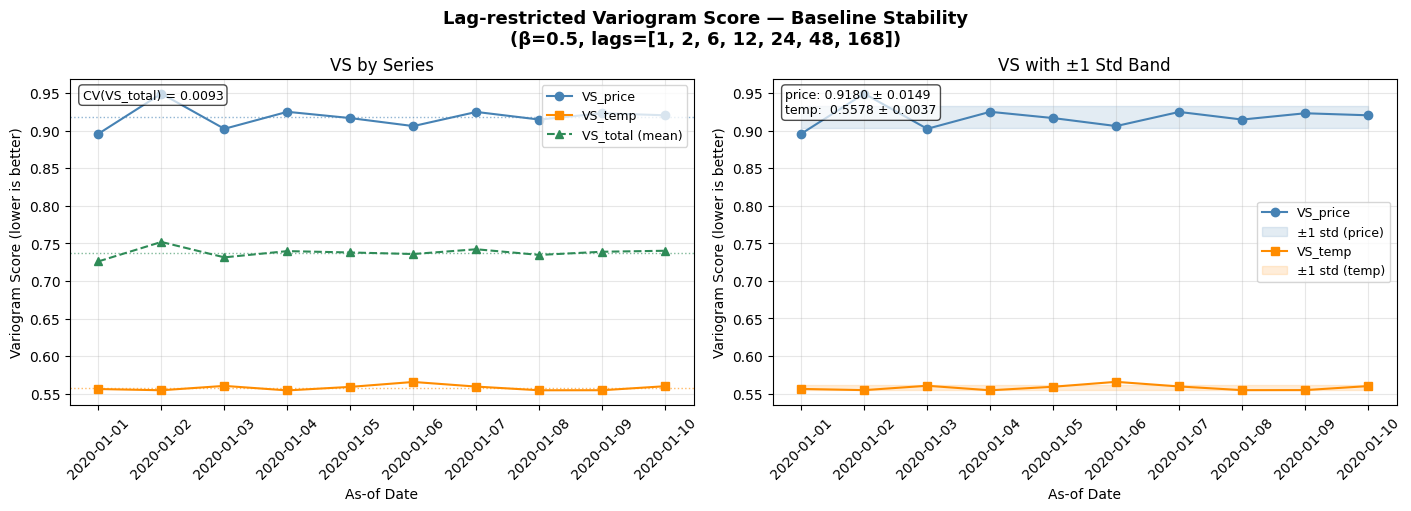

In [39]:
# ============================================================
# STEP 10: Visualization — VS_total across as-of dates
# ============================================================

import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         constrained_layout=True)

fig.suptitle(
    "Lag-restricted Variogram Score — Baseline Stability\n"
    f"(β={beta_main}, lags={lags_main})",
    fontsize=13, fontweight='bold'
)

dates = vs_df['asof'].dt.date

# --- Left panel: VS by series ---
ax = axes[0]
ax.plot(dates, vs_df['vs_price'],
        marker='o', linewidth=1.5, color='steelblue',
        label='VS_price')
ax.plot(dates, vs_df['vs_temp'],
        marker='s', linewidth=1.5, color='darkorange',
        label='VS_temp')
ax.plot(dates, vs_df['vs_total'],
        marker='^', linewidth=1.5, color='seagreen',
        linestyle='--', label='VS_total (mean)')

# Reference lines: mean per series
ax.axhline(vs_df['vs_price'].mean(), color='steelblue',
           linestyle=':', linewidth=1.0, alpha=0.6)
ax.axhline(vs_df['vs_temp'].mean(),  color='darkorange',
           linestyle=':', linewidth=1.0, alpha=0.6)
ax.axhline(vs_df['vs_total'].mean(), color='seagreen',
           linestyle=':', linewidth=1.0, alpha=0.6)

ax.set_title("VS by Series")
ax.set_xlabel("As-of Date")
ax.set_ylabel("Variogram Score (lower is better)")
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Annotate CV
cv_total = vs_df['vs_total'].std() / vs_df['vs_total'].mean()
ax.text(0.02, 0.97,
        f"CV(VS_total) = {cv_total:.4f}",
        transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- Right panel: VS_price and VS_temp with ±1 std band ---
ax2 = axes[1]

mean_p = vs_df['vs_price'].mean()
std_p  = vs_df['vs_price'].std()
mean_t = vs_df['vs_temp'].mean()
std_t  = vs_df['vs_temp'].std()

ax2.plot(dates, vs_df['vs_price'],
         marker='o', linewidth=1.5, color='steelblue',
         label='VS_price')
ax2.fill_between(dates,
                 mean_p - std_p, mean_p + std_p,
                 color='steelblue', alpha=0.15,
                 label='±1 std (price)')

ax2.plot(dates, vs_df['vs_temp'],
         marker='s', linewidth=1.5, color='darkorange',
         label='VS_temp')
ax2.fill_between(dates,
                 mean_t - std_t, mean_t + std_t,
                 color='darkorange', alpha=0.15,
                 label='±1 std (temp)')

ax2.set_title("VS with ±1 Std Band")
ax2.set_xlabel("As-of Date")
ax2.set_ylabel("Variogram Score (lower is better)")
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Annotate mean ± std
ax2.text(0.02, 0.97,
         f"price: {mean_p:.4f} ± {std_p:.4f}\n"
         f"temp:  {mean_t:.4f} ± {std_t:.4f}",
         transform=ax2.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.show()

In [40]:

# ============================================================
# STEP 11-13: Violation Rate, Interval Width, Tail Exceedance
# Part 1: Parameter Setup
# ============================================================

# --- Quantile definitions ---
q_low_90,  q_high_90  = 0.05,  0.95
q_low_95,  q_high_95  = 0.025, 0.975
q_tail_lo, q_tail_hi  = 0.01,  0.99   # VaR-style tails

# --- Lead-time buckets (0-based internal indexing) ---
# horizons: 0..8759 corresponds to lead-time hours 1..8760
buckets = {
    "intraday":  (0, 24),     # lead-time 1..24
    "weekly":    (24, 168),   # lead-time 25..168
    "monthly":   (168, 720),  # lead-time 169..720
    "long_term": (720, 8760)  # lead-time 721..8760
}

H = 8760
horizons = np.arange(H)  # 0..8759

def get_bucket_mask(horizons, low_inclusive, high_exclusive):
    """
    horizons: 0-based array [0..H-1], corresponding to lead-time hours [1..H]
    Bucket definition uses 0-based indexing internally:
      horizons in [low_inclusive, high_exclusive)
    Example:
      [0, 24) -> lead-time hours 1..24
    """
    return (horizons >= low_inclusive) & (horizons < high_exclusive)

bucket_masks = {
    name: get_bucket_mask(horizons, low, high)
    for name, (low, high) in buckets.items()
}

# Verify coverage (no gaps, no overlaps)
total_covered = sum(mask.sum() for mask in bucket_masks.values())
assert total_covered == H, f"Bucket coverage error: {total_covered} != {H}"

# Optional: verify disjointness (overlap check)
overlap_count = np.sum(np.stack(list(bucket_masks.values()), axis=0), axis=0)
assert np.all(overlap_count == 1), "Bucket overlap or gap detected (some horizons not assigned exactly once)."

print("Parameter Setup")
print("="*55)
print("Quantiles:")
print(f"  90% interval : [{q_low_90},  {q_high_90}]")
print(f"  95% interval : [{q_low_95}, {q_high_95}]")
print(f"  Tail lower   : q={q_tail_lo}  (y < q_0.01)")
print(f"  Tail upper   : q={q_tail_hi}  (y > q_0.99)")
print()
print("Lead-time buckets (hours since as-of):")
print(f"  {'Bucket':<12} {'Range':<18} {'n_horizons':>10}")
print("-"*45)
for name, (low, high) in buckets.items():
    n = bucket_masks[name].sum()
    # Convert 0-based [low, high) into 1-based [low+1, high]
    print(f"  {name:<12} h in [{low+1:>4}, {high:>4}] {n:>10}")
print("-"*45)
print(f"  {'Total':<12} {'':<18} {total_covered:>10}")

Parameter Setup
Quantiles:
  90% interval : [0.05,  0.95]
  95% interval : [0.025, 0.975]
  Tail lower   : q=0.01  (y < q_0.01)
  Tail upper   : q=0.99  (y > q_0.99)

Lead-time buckets (hours since as-of):
  Bucket       Range              n_horizons
---------------------------------------------
  intraday     h in [   1,   24]         24
  weekly       h in [  25,  168]        144
  monthly      h in [ 169,  720]        552
  long_term    h in [ 721, 8760]       8040
---------------------------------------------
  Total                                 8760


In [ ]:
# ============================================================
# STEP 11-13: Core Function to Compute Metrics by Bucket
# ============================================================

import warnings

def compute_coverage_metrics(sims, realized, bucket_masks,
                              q_low_90,  q_high_90,
                              q_low_95,  q_high_95,
                              q_tail_lo, q_tail_hi,
                              check_finite=False,
                              expect_H=None,
                              auto_orient=True):
    """
    Compute violation rate, interval width, and tail exceedance
    for a single as-of date, reported by lead-time bucket.

    Parameters
    ----------
    sims         : array-like, shape (H, N) or (N, H)
                   Simulated paths. Auto-oriented to (H, N) if
                   auto_orient=True.
    realized     : array-like, shape (H,)
                   Realized values
    bucket_masks : dict of {str: bool array (H,)}
                   Lead-time bucket masks
    q_low_90/q_high_90   : float — 90% interval quantiles
    q_low_95/q_high_95   : float — 95% interval quantiles
    q_tail_lo/q_tail_hi  : float — tail exceedance quantiles
    check_finite : bool — check for NaN/inf (single-point only)
    expect_H     : int or None — expected horizon dimension.
                   If provided, used to orient sims unambiguously.
                   Recommended: always pass expect_H=H explicitly.
    auto_orient  : bool — if True, auto-transpose sims if needed.

    Returns
    -------
    results : dict of {bucket_name: dict of metrics}
        Each bucket contains:
            viol_90    : violation rate, 90% interval
                         (nominal = 0.10 under correct spec)
            viol_95    : violation rate, 95% interval
                         (nominal = 0.05 under correct spec)
            width_90   : mean interval width, 90%
            width_95   : mean interval width, 95%
            exceed_lo  : lower tail exceedance (nominal = 0.01)
            exceed_hi  : upper tail exceedance (nominal = 0.01)
            n_horizons : number of horizons in bucket
    """

    # --- Type coercion ---
    sims     = np.asarray(sims,     dtype=float)
    realized = np.asarray(realized, dtype=float)

    # --- Shape checks ---
    if sims.ndim != 2:
        raise ValueError(
            f"sims must be 2D, got shape {sims.shape}")
    if realized.ndim != 1:
        raise ValueError(
            f"realized must be 1D, got shape {realized.shape}")

    # --- Auto-orient sims to (H, N) ---
    if auto_orient:
        if expect_H is not None:
            # Unambiguous: use expect_H
            if sims.shape[0] != expect_H and sims.shape[1] == expect_H:
                sims = sims.T
        else:
            # Heuristic: match realized length
            if sims.shape[0] == sims.shape[1]:
                warnings.warn(
                    f"sims is square ({sims.shape}); "
                    f"cannot auto-orient — pass expect_H explicitly."
                )
            elif (sims.shape[0] != realized.shape[0] and
                  sims.shape[1] == realized.shape[0]):
                sims = sims.T

    H, N = sims.shape

    if realized.shape[0] != H:
        raise ValueError(
            f"realized length {realized.shape[0]} != sims H {H}")

    # --- Optional finite check ---
    if check_finite:
        if not np.isfinite(sims).all():
            raise ValueError("non-finite values in sims")
        if not np.isfinite(realized).all():
            raise ValueError("non-finite values in realized")

    # --- Compute quantile bounds: shape (H,) ---
    lo_90   = np.quantile(sims, q_low_90,  axis=1) 
    hi_90   = np.quantile(sims, q_high_90, axis=1)
    lo_95   = np.quantile(sims, q_low_95,  axis=1)
    hi_95   = np.quantile(sims, q_high_95, axis=1)
    lo_tail = np.quantile(sims, q_tail_lo, axis=1)
    hi_tail = np.quantile(sims, q_tail_hi, axis=1)

    # --- Boolean arrays: shape (H,) ---
    viol_90_arr   = (realized < lo_90)  | (realized > hi_90)
    viol_95_arr   = (realized < lo_95)  | (realized > hi_95)
    exceed_lo_arr = (realized < lo_tail)
    exceed_hi_arr = (realized > hi_tail)
    width_90_arr  = hi_90 - lo_90
    width_95_arr  = hi_95 - lo_95

    # --- Aggregate by bucket ---
    results = {}

    for bucket_name, mask in bucket_masks.items():
        mask = np.asarray(mask, dtype=bool)

        if mask.shape[0] != H:
            raise ValueError(
                f"bucket mask '{bucket_name}' length "
                f"{mask.shape[0]} != H {H}")

        n = int(mask.sum())
        if n == 0:
            continue

        results[bucket_name] = {
            "viol_90":    float(viol_90_arr[mask].mean()),
            "viol_95":    float(viol_95_arr[mask].mean()),
            "width_90":   float(width_90_arr[mask].mean()),
            "width_95":   float(width_95_arr[mask].mean()),
            "exceed_lo":  float(exceed_lo_arr[mask].mean()),
            "exceed_hi":  float(exceed_hi_arr[mask].mean()),
            "n_horizons": n,
        }

    return results

In [42]:
# ============================================================
# STEP 11-13: Single-point Validation 
# Part 3: Single As-of Date
# ============================================================

asof_test = asof_dates[0]

sims_p = sims_dict[asof_test]['price'].values
sims_t = sims_dict[asof_test]['temp'].values
real_p = realized_dict['price'].loc[asof_test].values
real_t = realized_dict['temp'].loc[asof_test].values

results_p = compute_coverage_metrics(
    sims_p, real_p, bucket_masks,
    q_low_90, q_high_90,
    q_low_95, q_high_95,
    q_tail_lo, q_tail_hi,
    check_finite=True, expect_H=H
)

results_t = compute_coverage_metrics(
    sims_t, real_t, bucket_masks,
    q_low_90, q_high_90,
    q_low_95, q_high_95,
    q_tail_lo, q_tail_hi,
    check_finite=True, expect_H=H
)

bucket_order = ["intraday", "weekly", "monthly", "long_term"]

for series_name, results in [('price', results_p),
                              ('temp',  results_t)]:

    # --- Weighted overall ---
    total_h = sum(m['n_horizons'] for m in results.values())

    def wavg(key):
        return sum(
            m[key] * m['n_horizons']
            for m in results.values()
        ) / total_h

    print()
    print("="*72)
    print(f"Single as-of Validation: {asof_test.date()}  |  "
          f"Series: {series_name}")
    print("Nominal rates under correct specification: "
          "viol_90=0.10, viol_95=0.05, "
          "exceed_lo=0.01, exceed_hi=0.01")
    print("="*72)
    print(f"  {'Bucket':<12} {'n_h':>5}  "
          f"{'viol_90':>8} {'viol_95':>8}  "
          f"{'width_90':>9} {'width_95':>9}  "
          f"{'exc_lo':>7} {'exc_hi':>7}")
    print("-"*72)

    for bucket_name in bucket_order:
        m = results.get(bucket_name)

        # Defensive: bucket skipped (e.g. n_horizons=0)
        if m is None:
            print(f"  {bucket_name:<12} {'-':>5}  "
                  f"{'-':>8} {'-':>8}  "
                  f"{'-':>9} {'-':>9}  "
                  f"{'-':>7} {'-':>7}")
            continue

        print(f"  {bucket_name:<12} {m['n_horizons']:>5}  "
              f"{m['viol_90']:>8.4f} {m['viol_95']:>8.4f}  "
              f"{m['width_90']:>9.4f} {m['width_95']:>9.4f}  "
              f"{m['exceed_lo']:>7.4f} {m['exceed_hi']:>7.4f}")

    print("-"*72)

    print(f"  {'overall':<12} {total_h:>5}  "
          f"{wavg('viol_90'):>8.4f} {wavg('viol_95'):>8.4f}  "
          f"{wavg('width_90'):>9.4f} {wavg('width_95'):>9.4f}  "
          f"{wavg('exceed_lo'):>7.4f} {wavg('exceed_hi'):>7.4f}")


Single as-of Validation: 2020-01-01  |  Series: price
Nominal rates under correct specification: viol_90=0.10, viol_95=0.05, exceed_lo=0.01, exceed_hi=0.01
  Bucket         n_h   viol_90  viol_95   width_90  width_95   exc_lo  exc_hi
------------------------------------------------------------------------
  intraday        24    0.1250   0.0417    16.4986   19.6553   0.0000  0.0000
  weekly         144    0.0556   0.0417    16.4254   19.5638   0.0139  0.0000
  monthly        552    0.1214   0.0652    16.4497   19.5834   0.0091  0.0091
  long_term     8040    0.0945   0.0460    16.4417   19.5870   0.0092  0.0085
------------------------------------------------------------------------
  overall       8760    0.0957   0.0471    16.4421   19.5866   0.0092  0.0083

Single as-of Validation: 2020-01-01  |  Series: temp
Nominal rates under correct specification: viol_90=0.10, viol_95=0.05, exceed_lo=0.01, exceed_hi=0.01
  Bucket         n_h   viol_90  viol_95   width_90  width_95   exc_lo  ex

In [43]:
# ============================================================
# STEP 11-13: Full Evaluation 
# Part 4: Full Run
# ============================================================

import time

def weighted_overall(res):
    """
    Compute horizon-weighted overall metrics from bucket results.
    Raises ValueError if total_h == 0.
    """
    total_h = sum(m['n_horizons'] for m in res.values())
    if total_h == 0:
        raise ValueError(
            "total_h is 0: empty bucket results "
            "(check bucket_masks and H).")
    keys = ['viol_90', 'viol_95', 'width_90',
            'width_95', 'exceed_lo', 'exceed_hi']
    return {
        k: sum(m[k] * m['n_horizons']
               for m in res.values()) / total_h
        for k in keys
    }, total_h


def wmean(df, col, wcol='n_horizons'):
    """Horizon-weighted mean of col in df."""
    w = df[wcol].to_numpy()
    x = df[col].to_numpy()
    return float(np.sum(x * w) / np.sum(w))


# --- Storage ---
detail_results  = []   # asof × series × bucket
overall_results = []   # asof × series × overall

nominal_map = {
    'viol_90':   0.10,
    'viol_95':   0.05,
    'exceed_lo': 0.01,
    'exceed_hi': 0.01,
    'width_90':  None,
    'width_95':  None,
}

print("="*72)
print("Full Evaluation: all as-of dates")
print("="*72)

for asof in asof_dates:
    t_start = time.time()

    sims_p = sims_dict[asof]['price'].values
    sims_t = sims_dict[asof]['temp'].values
    real_p = realized_dict['price'].loc[asof].values
    real_t = realized_dict['temp'].loc[asof].values

    res_p = compute_coverage_metrics(
        sims_p, real_p, bucket_masks,
        q_low_90, q_high_90,
        q_low_95, q_high_95,
        q_tail_lo, q_tail_hi,
        check_finite=False, expect_H=H
    )
    res_t = compute_coverage_metrics(
        sims_t, real_t, bucket_masks,
        q_low_90, q_high_90,
        q_low_95, q_high_95,
        q_tail_lo, q_tail_hi,
        check_finite=False, expect_H=H
    )

    for series_name, res in [('price', res_p), ('temp', res_t)]:

        # --- Detail: by bucket ---
        for bucket_name in bucket_order:
            m = res.get(bucket_name)
            if m is None:
                continue
            detail_results.append({
                'asof':       asof,
                'series':     series_name,
                'bucket':     bucket_name,
                'viol_90':    m['viol_90'],
                'viol_95':    m['viol_95'],
                'width_90':   m['width_90'],
                'width_95':   m['width_95'],
                'exceed_lo':  m['exceed_lo'],
                'exceed_hi':  m['exceed_hi'],
                'n_horizons': m['n_horizons'],
            })

        # --- Overall: horizon-weighted ---
        ov, total_h = weighted_overall(res)
        overall_results.append({
            'asof':       asof,
            'series':     series_name,
            'n_horizons': total_h,
            **ov
        })

    t_elapsed = time.time() - t_start
    print(f"  {asof.date()}  ({t_elapsed:.2f}s)")

detail_df  = pd.DataFrame(detail_results)
overall_df = pd.DataFrame(overall_results)

# Add deviation columns to overall_df
for k, nom in nominal_map.items():
    if nom is not None and k in overall_df.columns:
        overall_df[f"{k}_dev"] = overall_df[k] - nom

# ============================================================
# Summary: overall by series
# ============================================================
metrics_to_report = ['viol_90', 'viol_95',
                     'width_90', 'width_95',
                     'exceed_lo', 'exceed_hi']

for series_name in ['price', 'temp']:
    df_s = overall_df[overall_df['series'] == series_name]

    print()
    print("="*72)
    print(f"Summary (overall, horizon-weighted): {series_name}")
    print("="*72)
    print(f"  {'Metric':<12} {'Mean':>8} {'Std':>8} "
          f"{'Min':>8} {'Max':>8}  "
          f"{'Nominal':>8} {'Mean Dev':>9}")
    print("-"*68)

    for col in metrics_to_report:
        mean = df_s[col].mean()
        std  = df_s[col].std()
        mn   = df_s[col].min()
        mx   = df_s[col].max()
        nom  = nominal_map[col]
        nom_str = f"{nom:.2f}" if nom is not None else "n/a"
        dev_str = f"{mean - nom:+.4f}" if nom is not None else "n/a"

        print(f"  {col:<12} {mean:>8.4f} {std:>8.4f} "
              f"{mn:>8.4f} {mx:>8.4f}  "
              f"{nom_str:>8} {dev_str:>9}")

# ============================================================
# Summary: by bucket (averaged across as-of dates)
# ============================================================
for series_name in ['price', 'temp']:
    df_s = detail_df[detail_df['series'] == series_name]

    print()
    print("="*72)
    print(f"Summary (by bucket): {series_name}")
    print("="*72)
    print(f"  {'Bucket':<12} {'n_h':>5}  "
          f"{'viol_90':>8} {'viol_95':>8}  "
          f"{'width_90':>9} {'width_95':>9}  "
          f"{'exc_lo':>7} {'exc_hi':>7}")
    print("-"*72)

    for bucket_name in bucket_order:
        df_b = df_s[df_s['bucket'] == bucket_name]
        if df_b.empty:
            continue

        # Assert n_horizons is constant across as-of dates
        assert df_b['n_horizons'].nunique() == 1, (
            f"n_horizons varies across as-of dates "
            f"for bucket '{bucket_name}' — check bucket_masks."
        )
        n_h = int(df_b['n_horizons'].iloc[0])

        print(f"  {bucket_name:<12} {n_h:>5}  "
              f"{wmean(df_b, 'viol_90'):>8.4f} "
              f"{wmean(df_b, 'viol_95'):>8.4f}  "
              f"{wmean(df_b, 'width_90'):>9.4f} "
              f"{wmean(df_b, 'width_95'):>9.4f}  "
              f"{wmean(df_b, 'exceed_lo'):>7.4f} "
              f"{wmean(df_b, 'exceed_hi'):>7.4f}")

Full Evaluation: all as-of dates
  2020-01-01  (7.59s)
  2020-01-02  (9.54s)
  2020-01-03  (9.87s)
  2020-01-04  (9.64s)
  2020-01-05  (8.41s)
  2020-01-06  (8.44s)
  2020-01-07  (8.18s)
  2020-01-08  (7.95s)
  2020-01-09  (8.29s)
  2020-01-10  (8.42s)

Summary (overall, horizon-weighted): price
  Metric           Mean      Std      Min      Max   Nominal  Mean Dev
--------------------------------------------------------------------
  viol_90        0.0995   0.0043   0.0945   0.1087      0.10   -0.0005
  viol_95        0.0503   0.0030   0.0461   0.0556      0.05   +0.0003
  width_90      16.4385   0.0023  16.4343  16.4421       n/a       n/a
  width_95      19.5809   0.0035  19.5765  19.5866       n/a       n/a
  exceed_lo      0.0101   0.0010   0.0089   0.0121      0.01   +0.0001
  exceed_hi      0.0102   0.0010   0.0083   0.0116      0.01   +0.0002

Summary (overall, horizon-weighted): temp
  Metric           Mean      Std      Min      Max   Nominal  Mean Dev
-----------------------

In [ ]:
import time
from scipy.stats import norm, anderson
from statsmodels.stats.diagnostic import acorr_ljungbox

# ============================================================
# PHASE B: Monte Carlo Null Study
# Purpose: estimate empirical Type I error (size) under correct specification
# Design:  Truth  ← baseline DGP
#          Forecast ← same correctly specified DGP
# ============================================================

N_rep         = 500   # MC repetitions
n_paths_mc    = 500   # simulation paths per rep
n_horizons_mc = 720   # 30 days × 24h
alpha         = 0.05  # nominal significance level

# DGP parameters — identical to Phase A
base_price_mc    = 50.0
amp_price_day_mc = 10.0
amp_price_year_mc = 5.0
base_temp_mc     = 10.0
amp_temp_day_mc  = 8.0
amp_temp_year_mc = 12.0
sigma_price_mc   = 5.0
sigma_temp_mc    = 3.0
rho_mc           = 0.5

cov_mc = np.array([
    [sigma_price_mc**2,                        rho_mc * sigma_price_mc * sigma_temp_mc],
    [rho_mc * sigma_price_mc * sigma_temp_mc,  sigma_temp_mc**2                       ]
])
L_mc = np.linalg.cholesky(cov_mc)

# Fixed as-of date → precompute seasonality means
asof_fixed_mc = pd.Timestamp('2020-01-01')
dt_index_mc   = pd.date_range(asof_fixed_mc, periods=n_horizons_mc, freq='h')
hod_mc        = dt_index_mc.hour.values
doy_mc        = dt_index_mc.dayofyear.values
day_phase_mc  = 2 * np.pi * hod_mc / 24.0
year_phase_mc = 2 * np.pi * (doy_mc - 1) / 365.0

mean_price_mc = (
    base_price_mc
    + amp_price_day_mc  * (0.8 * np.sin(day_phase_mc - np.pi)
                           + 0.2 * np.sin(2 * (day_phase_mc - np.pi)))
    + amp_price_year_mc * np.cos(year_phase_mc)
)
mean_temp_mc = (
    base_temp_mc
    - amp_temp_day_mc  * np.cos(2 * np.pi * (hod_mc - 5) / 24.0)
    + amp_temp_year_mc * np.cos(year_phase_mc + np.pi)
)

print(f'Phase B setup complete.')
print(f'  N_rep={N_rep}, n_paths_mc={n_paths_mc}, n_horizons_mc={n_horizons_mc}')
print(f'  mean_price range: [{mean_price_mc.min():.1f}, {mean_price_mc.max():.1f}]')
print(f'  mean_temp  range: [{mean_temp_mc.min():.1f}, {mean_temp_mc.max():.1f}]')


In [ ]:
# ============================================================
# PHASE B: Fixed standardisation parameters for Energy Score
# Drawn from a large reference sample under correct specification.
# Using a fixed seed ensures these params are identical across all reps.
# ============================================================

ref_rng_mc = np.random.default_rng(9999)
n_ref_mc   = 2000

Z_ref_mc   = ref_rng_mc.standard_normal((n_horizons_mc, n_ref_mc, 2))
eps_ref_mc = Z_ref_mc @ L_mc.T
ref_price_mc = (mean_price_mc[:, None] + eps_ref_mc[:, :, 0]).flatten()
ref_temp_mc  = (mean_temp_mc[:, None]  + eps_ref_mc[:, :, 1]).flatten()

mu_p_mc  = float(ref_price_mc.mean())
std_p_mc = float(ref_price_mc.std())
mu_t_mc  = float(ref_temp_mc.mean())
std_t_mc = float(ref_temp_mc.std())

del Z_ref_mc, eps_ref_mc, ref_price_mc, ref_temp_mc  # free memory

print(f'ES standardisation params (from {n_ref_mc}-path reference sample):')
print(f'  price: mu={mu_p_mc:.4f}, std={std_p_mc:.4f}')
print(f'  temp:  mu={mu_t_mc:.4f}, std={std_t_mc:.4f}')


In [ ]:
# ── Phase B MC loop ──────────────────────────────────────────────
# ============================================================
# PHASE B: Monte Carlo loop
# Each rep: draw truth + draw correctly-specified forecast,
#           compute null-study diagnostics, record results.
# Diagnostics: PIT/KS, AD, LB, ES, VS
# Note: coverage metrics excluded from Phase B null study;
#       lag 720 skipped (>= H=720).
# ============================================================

lags_lb_mc = [24, 168]  # lag 720 >= n_horizons_mc, excluded

def _pit(sims, realized, rng):
    """Rank-based randomized PIT, output in (0,1)."""
    sorted_s = np.sort(sims, axis=1)
    H, N     = sims.shape
    ranks    = np.array(
        [np.searchsorted(sorted_s[i], realized[i], side='right')
         for i in range(H)], dtype=float)
    u = rng.uniform(0.0, 1.0, size=ranks.shape)
    return np.clip((ranks + u) / (N + 1.0), 1e-6, 1 - 1e-6)

rng_mc     = np.random.default_rng(1234)  # master RNG: truth + sims + PIT
records_mc = []
t0         = time.time()

for rep in range(N_rep):

    # 1. Draw realized (truth) from true DGP
    Z_real_mc    = rng_mc.standard_normal((n_horizons_mc, 2))
    eps_real_mc  = Z_real_mc @ L_mc.T
    real_p_mc    = mean_price_mc + eps_real_mc[:, 0]
    real_t_mc    = mean_temp_mc  + eps_real_mc[:, 1]

    # 2. Draw forecast ensemble from same (correct) DGP
    Z_sims_mc    = rng_mc.standard_normal((n_horizons_mc, n_paths_mc, 2))
    eps_sims_mc  = Z_sims_mc @ L_mc.T
    sims_p_mc    = mean_price_mc[:, None] + eps_sims_mc[:, :, 0]  # (720, 500)
    sims_t_mc    = mean_temp_mc[:, None]  + eps_sims_mc[:, :, 1]

    # 3. PIT
    pit_p_mc = _pit(sims_p_mc, real_p_mc, rng_mc)
    pit_t_mc = _pit(sims_t_mc, real_t_mc, rng_mc)

    # 4. KS test: PIT ~ Uniform(0,1)?
    ks_p_pval = stats.kstest(pit_p_mc, 'uniform').pvalue
    ks_t_pval = stats.kstest(pit_t_mc, 'uniform').pvalue

    # 5. AD test: Gaussianized PIT ~ N(0,1)?
    z_p_mc  = norm.ppf(pit_p_mc)
    z_t_mc  = norm.ppf(pit_t_mc)
    ad_p_mc = anderson(z_p_mc, dist='norm')
    ad_t_mc = anderson(z_t_mc, dist='norm')
    # price/temp take their own critical values separately (more rigorous)
    ad_crit_p = ad_p_mc.critical_values[2]  # alpha=5%, index 2
    ad_crit_t = ad_t_mc.critical_values[2]

    # 6. Ljung-Box: serial dependence in Gaussianized PIT?
    lb_p_mc = acorr_ljungbox(z_p_mc, lags=lags_lb_mc, return_df=True)
    lb_t_mc = acorr_ljungbox(z_t_mc, lags=lags_lb_mc, return_df=True)

    # 7. Energy Score
    # ES internal subsampling uses independent RNG (separated from master rng_mc)
    # seed = 10_000 + rep ensures reproducibility per rep
    es_rng = np.random.default_rng(10_000 + rep)
    es_mc, _, _ = energy_score(
        sims_p_mc, sims_t_mc, real_p_mc, real_t_mc,
        mu_p_mc, std_p_mc, mu_t_mc, std_t_mc,
        M=200, R=3, seed=int(es_rng.integers(1_000_000))
    )

    # 8. Variogram Score
    vs_p_mc, _ = lag_variogram_score(sims_p_mc, real_p_mc, lags_main, w_norm, beta=0.5)
    vs_t_mc, _ = lag_variogram_score(sims_t_mc, real_t_mc, lags_main, w_norm, beta=0.5)
    vs_tot_mc  = 0.5 * (vs_p_mc + vs_t_mc)

    # Store results
    rec = {
        'rep':      rep,
        'ks_rej_p': int(ks_p_pval < alpha),
        'ks_rej_t': int(ks_t_pval < alpha),
        'ad_rej_p': int(ad_p_mc.statistic > ad_crit_p),
        'ad_rej_t': int(ad_t_mc.statistic > ad_crit_t),
        'es':       es_mc,
        'vs_p':     vs_p_mc,
        'vs_t':     vs_t_mc,
        'vs_total': vs_tot_mc,
    }
    for lag in lags_lb_mc:
        rec[f'lb_rej_p_{lag}'] = int(lb_p_mc.loc[lag, 'lb_pvalue'] < alpha)
        rec[f'lb_rej_t_{lag}'] = int(lb_t_mc.loc[lag, 'lb_pvalue'] < alpha)

    records_mc.append(rec)

    if (rep + 1) % 50 == 0:
        print(f'  rep {rep+1:>4}/{N_rep}  elapsed {time.time()-t0:.1f}s')

mc_df = pd.DataFrame(records_mc)
print(f'\nPhase B complete.  Total time: {time.time()-t0:.1f}s')


In [ ]:
# ============================================================
# PHASE B: Results Summary
# 1. Empirical rejection rates for KS / AD / LB  (nominal = 0.05)
# 2. Empirical null distributions for ES and VS
# 3. 95th-percentile alarm thresholds for ES / VS (optional governance use)
# ============================================================

print('=' * 60)
print(f'Phase B Empirical Rejection Rates  (α={alpha}, N_rep={N_rep})')
print('=' * 60)
print(f'  (Under correct specification, each rate should be ≈ {alpha})')
print()

reject_cols = {
    'KS  price':  'ks_rej_p',
    'KS  temp':   'ks_rej_t',
    'AD  price':  'ad_rej_p',
    'AD  temp':   'ad_rej_t',
}
for lag in lags_lb_mc:
    reject_cols[f'LB  price  lag={lag}'] = f'lb_rej_p_{lag}'
    reject_cols[f'LB  temp   lag={lag}'] = f'lb_rej_t_{lag}'

print(f'  {"Test":<22} {"Rej. Rate":>10} {"95% CI":>18}')
print(f'  {"-"*55}')
for label, col in reject_cols.items():
    rate = mc_df[col].mean()
    # Wald 95% CI for binomial proportion
    se   = np.sqrt(rate * (1 - rate) / N_rep)
    print(f'  {label:<22} {rate:>10.4f}  [{rate-1.96*se:.4f}, {rate+1.96*se:.4f}]')

print()
print('=' * 60)
print('Phase B ES / VS  —  null distribution summary')
print('=' * 60)
for col in ['es', 'vs_p', 'vs_t', 'vs_total']:
    vals = mc_df[col]
    print(f'  {col:<12}  mean={vals.mean():.4f}  std={vals.std():.4f}  '
          f'p95={vals.quantile(0.95):.4f}')

# Empirical 95th-percentile alarm thresholds
es_threshold  = mc_df['es'].quantile(0.95)
vs_threshold  = mc_df['vs_total'].quantile(0.95)
print()
print(f'Empirical alarm thresholds (95th pct under null):')
print(f'  ES  ≥ {es_threshold:.4f}  → alarm')
print(f'  VS  ≥ {vs_threshold:.4f}  → alarm')

# ---- Visualisation ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig.suptitle(
    f'Phase B — Null Distributions  '
    f'(N_rep={N_rep}, n_paths={n_paths_mc}, H={n_horizons_mc})',
    fontsize=12, fontweight='bold'
)

axes[0].hist(mc_df['es'], bins=30, edgecolor='k', alpha=0.7, color='steelblue')
axes[0].axvline(es_threshold, color='red', linestyle='--',
                label=f'95th pct = {es_threshold:.3f}')
axes[0].set_title('Energy Score — null distribution')
axes[0].set_xlabel('ES')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(mc_df['vs_total'], bins=30, edgecolor='k', alpha=0.7, color='darkorange')
axes[1].axvline(vs_threshold, color='red', linestyle='--',
                label=f'95th pct = {vs_threshold:.3f}')
axes[1].set_title('Variogram Score (total) — null distribution')
axes[1].set_xlabel('VS')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.show()
